## Import Libraries

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.15.0


In [5]:
train_dir = "Fruits and Vegetables Dataset/train"
test_dir  = "Fruits and Vegetables Dataset/test"
val_dir   = "Fruits and Vegetables Dataset/validation"

for dirpath, dirnames, filenames in os.walk(train_dir):
    if len(filenames) > 0:
        print(f"There are {len(filenames)} images in '{dirpath}'.")

There are 68 images in 'Fruits and Vegetables Dataset/train\apple'.
There are 75 images in 'Fruits and Vegetables Dataset/train\banana'.
There are 88 images in 'Fruits and Vegetables Dataset/train\beetroot'.
There are 90 images in 'Fruits and Vegetables Dataset/train\bell pepper'.
There are 92 images in 'Fruits and Vegetables Dataset/train\cabbage'.
There are 89 images in 'Fruits and Vegetables Dataset/train\capsicum'.
There are 82 images in 'Fruits and Vegetables Dataset/train\carrot'.
There are 79 images in 'Fruits and Vegetables Dataset/train\cauliflower'.
There are 87 images in 'Fruits and Vegetables Dataset/train\chilli pepper'.
There are 87 images in 'Fruits and Vegetables Dataset/train\corn'.
There are 94 images in 'Fruits and Vegetables Dataset/train\cucumber'.
There are 84 images in 'Fruits and Vegetables Dataset/train\eggplant'.
There are 92 images in 'Fruits and Vegetables Dataset/train\garlic'.
There are 68 images in 'Fruits and Vegetables Dataset/train\ginger'.
There are 1

## Load and Prepare the Data

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=val_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE
)

Found 3115 files belonging to 36 classes.
Found 359 files belonging to 36 classes.
Found 351 files belonging to 36 classes.


In [7]:
# Check the class names
class_names = train_data.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Class names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Number of classes: 36


## Visualize Sample Images

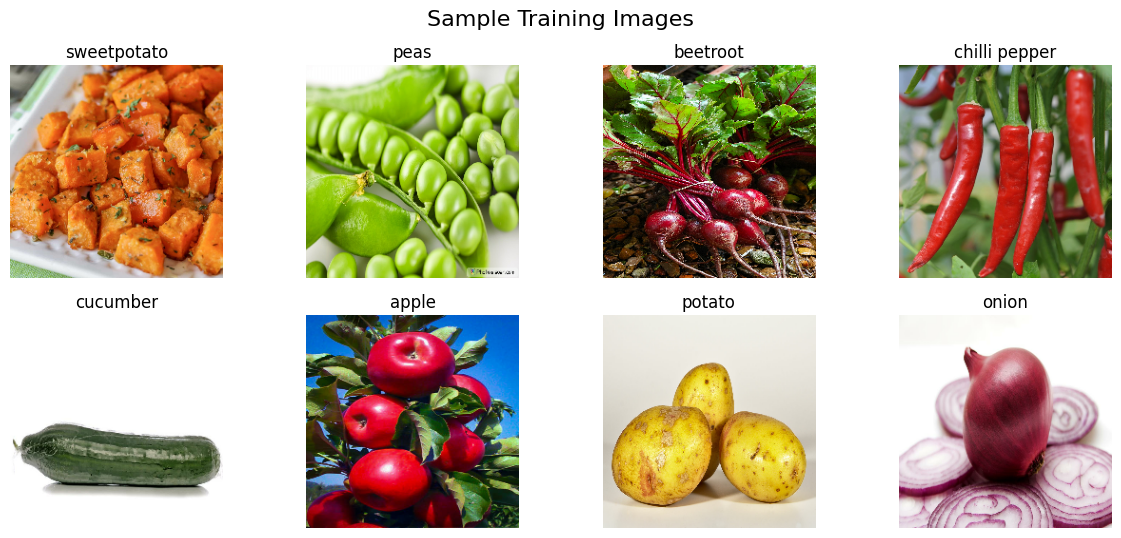

In [8]:
plt.figure(figsize=(12, 8))
for images, labels in train_data.take(1):
    for i in range(8):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i]).numpy()])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

## Create Data Augmentation Layer

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),      
    layers.RandomRotation(0.2),          
    layers.RandomZoom(0.2),                
    layers.RandomHeight(0.2),              
    layers.RandomWidth(0.2),                
], name="data_augmentation")

print("Data augmentation layer created!")


Data augmentation layer created!


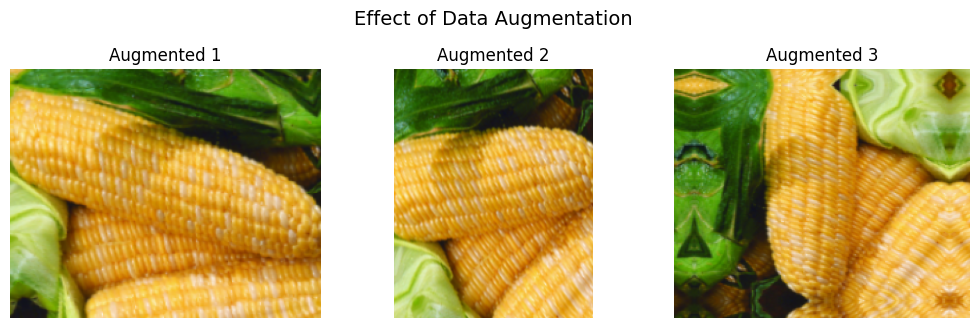

In [10]:
plt.figure(figsize=(10, 6))
for images, _ in train_data.take(1):
    sample_image = images[0]
    for i in range(3):
        augmented = data_augmentation(tf.expand_dims(sample_image, axis=0))
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(augmented).numpy().astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis("off")
plt.suptitle("Effect of Data Augmentation", fontsize=14)
plt.tight_layout()
plt.show()

## Helper Functions

In [11]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(loss))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [12]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects (before and after fine-tuning).
    """
    acc     = original_history.history["accuracy"]
    loss    = original_history.history["loss"]
    val_acc  = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    total_acc     = acc     + new_history.history["accuracy"]
    total_loss    = loss    + new_history.history["loss"]
    total_val_acc  = val_acc  + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(total_acc, label="training_accuracy")
    plt.plot(total_val_acc, label="val_accuracy")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(total_loss, label="training_loss")
    plt.plot(total_val_loss, label="val_loss")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Setup Callbacks

In [13]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    """
    Creates a TensorBoard callback to log model training metrics.
    """
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    print(f"Saving TensorBoard log files to: {log_dir}")
    return tensorboard_callback

In [14]:
checkpoint_path = "model_checkpoints/checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,  
    save_best_only=True,     
    save_freq="epoch",       
    verbose=1
)

print(f"Model weights will be saved to: {checkpoint_path}")

Model weights will be saved to: model_checkpoints/checkpoint.weights.h5


## Build the Model (Feature Extraction)

In [15]:
# 1. Create the EfficientNetB0 base model (without the top layer)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)

# 2. Freeze all layers in the base model
#    (we don't want to change the patterns it already learned)
base_model.trainable = False

# 3. Create the input layer
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")

# 4. Pass inputs through the data augmentation layer
x = data_augmentation(inputs)

# 5. Pass augmented inputs into the base model (training=False keeps BatchNorm frozen)
x = base_model(x, training=False)

# 6. Pool the output of the base model into a feature vector
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# 7. Create the output layer with the number of classes in our dataset
outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x)

# 8. Build the full model
model = keras.Model(inputs, outputs)

print("Model built successfully!")


Model built successfully!


In [16]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

In [17]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_average_pooling_lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 output_layer (Dense)        (None, 36)                46116 

## Train the Model — Feature Extraction

In [18]:
initial_epochs = 5

history_feature_extraction = model.fit(
    train_data,
    epochs=initial_epochs,
    validation_data=val_data,
    validation_steps=int(0.25 * len(val_data)), 
    callbacks=[
        create_tensorboard_callback("transfer_learning", "feature_extraction"),
        checkpoint_callback
    ]
)

Saving TensorBoard log files to: transfer_learning/feature_extraction/20260303-172617
Epoch 1/5


98/98 [==============================] - ETA: 0s - loss: 2.0340 - accuracy: 0.5313   
Epoch 1: val_loss improved from inf to 0.73717, saving model to model_checkpoints\checkpoint.weights.h5
98/98 [==============================] - 155s 1s/step - loss: 2.0340 - accuracy: 0.5313 - val_loss: 0.7372 - val_accuracy: 0.8594
Epoch 2/5
98/98 [==============================] - ETA: 0s - loss: 0.9068 - accuracy: 0.7865   
Epoch 2: val_loss improved from 0.73717 to 0.37842, saving model to model_checkpoints\checkpoint.weights.h5
98/98 [==============================] - 125s 1s/step - loss: 0.9068 - accuracy: 0.7865 - val_loss: 0.3784 - val_accuracy: 0.9531
Epoch 3/5
98/98 [==============================] - ETA: 0s - loss: 0.6590 - accuracy: 0.8334   
Epoch 3: val_loss did not improve from 0.37842
98/98 [==============================] - 125s 1s/step - loss: 0.6590 - accuracy: 0.8334 - val_loss: 0.392

In [19]:
print("Evaluating on test data...")
results_feature_extraction = model.evaluate(test_data)
print(f"\nTest Loss: {results_feature_extraction[0]:.4f}")
print(f"Test Accuracy: {results_feature_extraction[1]:.4f}")

Evaluating on test data...
12/12 [==============================] - 18s 830ms/step - loss: 0.2921 - accuracy: 0.9053

Test Loss: 0.2921
Test Accuracy: 0.9053


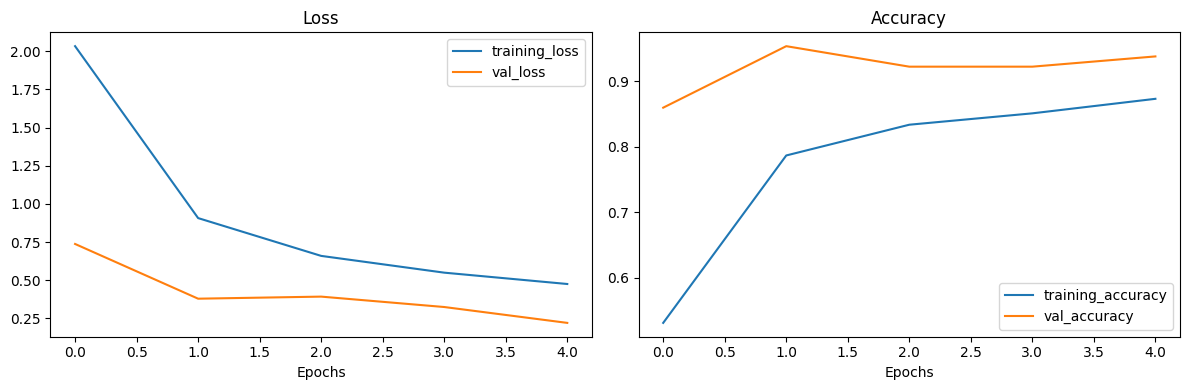

In [20]:
plot_loss_curves(history_feature_extraction)

## Fine-Tuning the Model

In [21]:
base_model_layer = model.layers[2]

base_model_layer.trainable = True

for layer in base_model_layer.layers[:-10]:
    layer.trainable = False

print(f"Number of trainable variables: {len(model.trainable_variables)}")

Number of trainable variables: 12


In [22]:
for layer_number, layer in enumerate(base_model_layer.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze False
39

In [23]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower than before
    metrics=["accuracy"]
)

In [24]:
fine_tune_epochs = initial_epochs + 5

history_fine_tuning = model.fit(
    train_data,
    epochs=fine_tune_epochs,
    initial_epoch=history_feature_extraction.epoch[-1], 
    validation_data=val_data,
    validation_steps=int(0.25 * len(val_data)),
    callbacks=[
        create_tensorboard_callback("transfer_learning", "fine_tuning")
    ]
)

Saving TensorBoard log files to: transfer_learning/fine_tuning/20260303-173756
Epoch 5/10
98/98 [==============================] - 165s 1s/step - loss: 0.3564 - accuracy: 0.8886 - val_loss: 0.2377 - val_accuracy: 0.8594
Epoch 6/10
98/98 [==============================] - 149s 1s/step - loss: 0.2860 - accuracy: 0.9047 - val_loss: 0.1685 - val_accuracy: 0.9219
Epoch 7/10
98/98 [==============================] - 150s 1s/step - loss: 0.2546 - accuracy: 0.9146 - val_loss: 0.1781 - val_accuracy: 0.8906
Epoch 8/10
98/98 [==============================] - 154s 2s/step - loss: 0.2235 - accuracy: 0.9255 - val_loss: 0.1955 - val_accuracy: 0.8906
Epoch 9/10
98/98 [==============================] - 146s 1s/step - loss: 0.2022 - accuracy: 0.9345 - val_loss: 0.1240 - val_accuracy: 0.9844
Epoch 10/10
98/98 [==============================] - 124s 1s/step - loss: 0.1796 - accuracy: 0.9403 - val_loss: 0.1542 - val_accuracy: 0.9219


In [25]:
print("Evaluating fine-tuned model on test data...")
results_fine_tuning = model.evaluate(test_data)
print(f"\nTest Loss: {results_fine_tuning[0]:.4f}")
print(f"Test Accuracy: {results_fine_tuning[1]:.4f}")

Evaluating fine-tuned model on test data...
12/12 [==============================] - 10s 492ms/step - loss: 0.1649 - accuracy: 0.9415

Test Loss: 0.1649
Test Accuracy: 0.9415


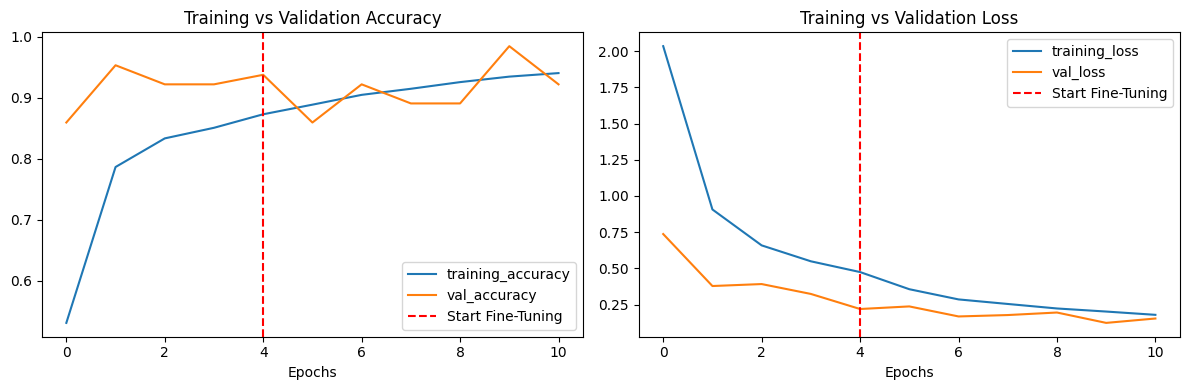

In [29]:
compare_historys(
    original_history=history_feature_extraction,
    new_history=history_fine_tuning,
    initial_epochs=initial_epochs
)

## Make Predictions

1/1 [==============================] - 1s 669ms/step


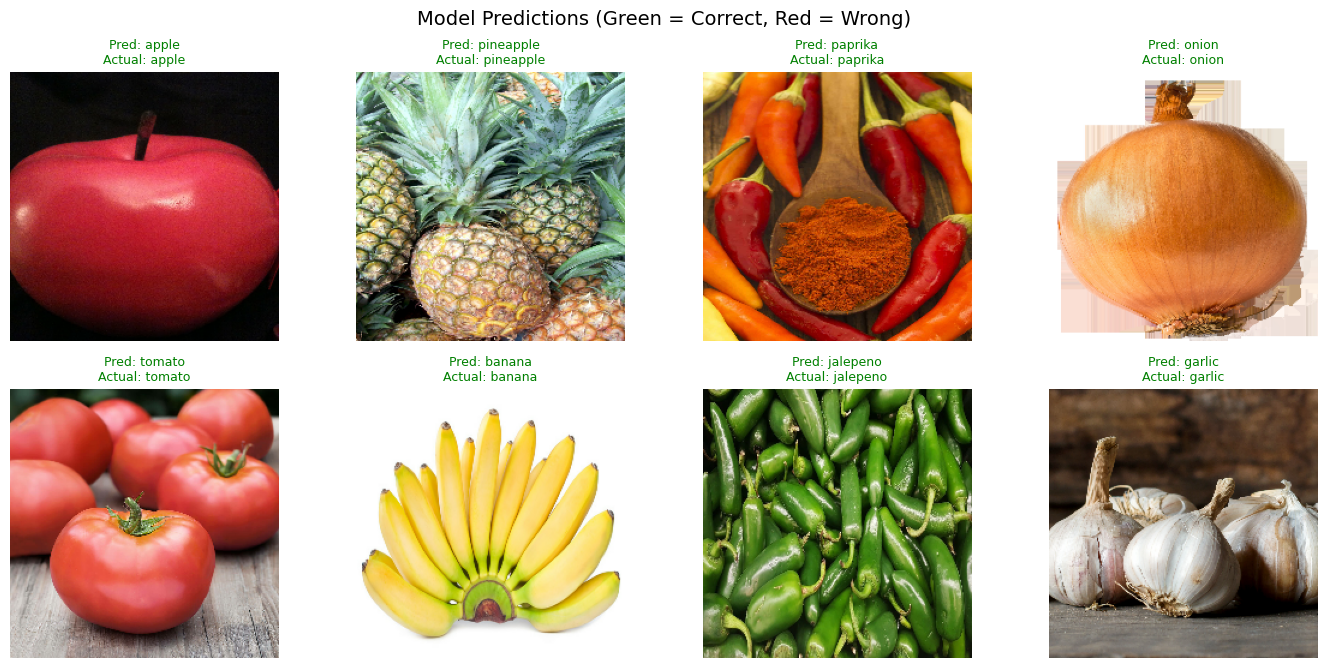

In [32]:
plt.figure(figsize=(14, 10))

for images, labels in test_data.take(1):
    predictions = model.predict(images)

    for i in range(8):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[tf.argmax(predictions[i]).numpy()]
        actual_class = class_names[tf.argmax(labels[i]).numpy()]

        color = "green" if predicted_class == actual_class else "red"
        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}", color=color, fontsize=9)
        plt.axis("off")

plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=14)
plt.tight_layout()
plt.show()